# SARIMA-Based Waste Forecasting

In [15]:
!pip install pmdarima optuna

In [16]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

MEALS    = ['breakfast', 'lunch', 'dinner']
TARGET   = 'waste_kg'
SECTIONS = ['a', 'b', 'c', 'd']


In [17]:
# 2. Mount Google Drive and set working directory
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence')
    print('Directory changed')
except OSError:
    print("Error: Can't change the Current Working Directory")


Mounted at /content/drive
Directory changed


## 3. Load and Inspect Dataset

In [18]:
def load_and_filter(path: str, meals: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f'Raw dataset shape: {df.shape}')
    print('Meal values:', df['meal'].unique())
    df = df[df['meal'].isin(meals)].copy()
    print(f'After filtering: {df.shape}')
    return df

df_raw = load_and_filter('data/waste_features_xgb.csv', MEALS)
df_raw.head()


Raw dataset shape: (2506, 33)
Meal values: ['lunch' 'breakfast' 'closed' 'dinner']
After filtering: (1813, 33)


,meal,waste_kg,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg,foot_traffic,is_holiday,has_special_event,year,month,...,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,section_encoded,section_a,section_b,section_c,section_d
0,lunch,5.17,2.74,1.75,0.68,102.00,0,1,2025,1,...,0.18,2.262857,2.102857,2.249257,5.58,0,True,False,False,False
1,breakfast,4.26,1.74,1.27,1.24,46.25,0,1,2025,1,...,3.18,2.854286,2.396429,2.133197,5.58,0,True,False,False,False
3,dinner,2.72,1.72,0.75,0.25,75.00,0,1,2025,1,...,0.06,2.147143,2.390000,1.978819,5.17,0,True,False,False,False
4,lunch,6.07,3.12,2.06,0.89,138.00,0,1,2025,1,...,1.50,2.842857,2.810000,2.401317,6.07,0,True,False,False,False
5,breakfast,2.96,1.21,0.89,0.85,46.00,0,1,2025,1,...,1.82,3.244286,2.786429,2.090940,6.07,0,True,False,False,False


## 4. Preprocess Data — Build Per-(Section, Meal) Time Series

In [19]:
def identify_section(row) -> str:
    for s in SECTIONS:
        if row.get(f'section_{s}', False):
            return s
    return None


def build_series_dict(df_raw: pd.DataFrame) -> dict:
    df = df_raw.copy()
    df['ds']      = pd.to_datetime(df[['year', 'month', 'day']])
    df['section'] = df.apply(identify_section, axis=1)
    df            = df.rename(columns={'meal': 'meal_type'})

    result = {}
    for sec in SECTIONS:
        result[sec] = {}
        sec_df = df[df['section'] == sec]
        for meal in MEALS:
            meal_df = sec_df[sec_df['meal_type'] == meal].sort_values('ds').set_index('ds')[[TARGET]].squeeze()
            result[sec][meal] = meal_df
            print(f'Section {sec.upper()} / {meal}: {len(meal_df)} observations')
    return result


series_dict = build_series_dict(df_raw)

Section A / breakfast: 153 observations
Section A / lunch: 147 observations
Section A / dinner: 155 observations
Section B / breakfast: 153 observations
Section B / lunch: 145 observations
Section B / dinner: 158 observations
Section C / breakfast: 157 observations
Section C / lunch: 140 observations
Section C / dinner: 159 observations
Section D / breakfast: 152 observations
Section D / lunch: 135 observations
Section D / dinner: 159 observations


## 5. Time-Based Train/Test Split

In [20]:
TEST_DAYS = 30

def make_sarima_splits(series_dict: dict, test_days: int = TEST_DAYS) -> dict:
    splits = {}
    for sec in SECTIONS:
        splits[sec] = {}
        all_dates = sorted(set().union(*[
            set(series_dict[sec][meal].index) for meal in MEALS
        ]))
        cutoff = all_dates[-test_days]

        for meal in MEALS:
            s     = series_dict[sec][meal]
            train = s[s.index < cutoff]
            test  = s[s.index >= cutoff]
            splits[sec][meal] = {'train': train, 'test': test}

        print(f'Section {sec.upper()} | cutoff: {cutoff.date()} | '
              f'train: {len(splits[sec]["breakfast"]["train"])} | '
              f'test: {len(splits[sec]["breakfast"]["test"])}')
    return splits


splits = make_sarima_splits(series_dict)

Section A | cutoff: 2025-06-01 | train: 123 | test: 30
Section B | cutoff: 2025-06-01 | train: 129 | test: 24
Section C | cutoff: 2025-05-31 | train: 132 | test: 25
Section D | cutoff: 2025-06-01 | train: 127 | test: 25


## 6. Evaluation Helpers

In [21]:
def evaluate_sarima(model, test_series: pd.Series) -> tuple:
    n      = len(test_series)
    preds  = model.predict(n)
    actual = test_series.values

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) /
                           np.where(actual == 0, 1e-9, actual))) * 100
    r2   = r2_score(actual, preds)
    return rmse, mae, mape, r2, preds

## 7. Baseline SARIMA Models

In [22]:
def train_auto_arima(train_series: pd.Series, seasonal: bool = True,
                     m: int = 7) -> pm.ARIMA:
    """Fit auto_arima baseline with weekly seasonality."""
    model = auto_arima(
        train_series,
        start_p=1, max_p=3,
        start_q=0, max_q=3,
        d=None,                  # auto-select via unit-root test
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        D=None,
        seasonal=seasonal,
        m=m,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    return model


baseline_results = []

for sec in SECTIONS:
    for meal in MEALS:
        print(f'Fitting baseline: Section {sec.upper()} / {meal} ...', end=' ')
        train = splits[sec][meal]['train']
        test  = splits[sec][meal]['test']

        model = train_auto_arima(train)
        order  = model.order
        s_order = model.seasonal_order
        print(f'order={order}, seasonal={s_order}')

        rmse, mae, mape, r2, _ = evaluate_sarima(model, test)
        baseline_results.append({
            'section': sec.upper(), 'meal': meal,
            'order': str(order), 'seasonal_order': str(s_order),
            'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2
        })

        os.makedirs('models/sarima_optimized', exist_ok=True)

        with open(f'models/sarima_optimized/baseline_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(model, f)

baseline_df = pd.DataFrame(baseline_results)
print('\nBaseline Performance')
print(baseline_df[['section','meal','order','seasonal_order',
                   'RMSE','MAE','MAPE','R2']].to_string(index=False))


Fitting baseline: Section A / breakfast ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section A / lunch ... order=(1, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section A / dinner ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section B / breakfast ... order=(0, 0, 0), seasonal=(0, 0, 1, 7)
Fitting baseline: Section B / lunch ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section B / dinner ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section C / breakfast ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section C / lunch ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section C / dinner ... order=(2, 1, 1), seasonal=(0, 0, 0, 7)
Fitting baseline: Section D / breakfast ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section D / lunch ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)
Fitting baseline: Section D / dinner ... order=(0, 0, 0), seasonal=(0, 0, 0, 7)

Baseline Performance
section   

## 8. Hyperparameter Refinement with Optuna

In [23]:
def sarima_objective(trial, train_series: pd.Series,
                      n_folds: int = 3) -> float:
    p = trial.suggest_int('p', 0, 3)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 3)
    P = trial.suggest_int('P', 0, 2)
    D = trial.suggest_int('D', 0, 1)
    Q = trial.suggest_int('Q', 0, 2)

    n         = len(train_series)
    fold_size = n // (n_folds + 1)
    rmse_scores = []

    for fold in range(n_folds):
        end_tr  = fold_size * (fold + 1)
        end_val = end_tr + fold_size
        tr  = train_series.iloc[:end_tr]
        val = train_series.iloc[end_tr:end_val]
        if len(tr) < 20 or len(val) == 0:
            continue
        try:
            m = pm.ARIMA(order=(p, d, q),
                         seasonal_order=(P, D, Q, 7),
                         suppress_warnings=True)
            m.fit(tr)
            preds = m.predict(len(val))
            rmse_scores.append(np.sqrt(mean_squared_error(val.values, preds)))
        except Exception:
            return 1e6

    return float(np.mean(rmse_scores)) if rmse_scores else 1e6


N_TRIALS    = 40
best_models = {sec: {} for sec in SECTIONS}
study_logs  = {sec: {} for sec in SECTIONS}

for sec in SECTIONS:
    for meal in MEALS:
        key = f'Section {sec.upper()} / {meal}'
        print(f"\nOptimising {key}\n")
        train = splits[sec][meal]['train']

        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=RANDOM_SEED),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        )

        def obj_wrapper(trial):
            return sarima_objective(trial, train)

        study.optimize(obj_wrapper, n_trials=N_TRIALS, show_progress_bar=True)
        study_logs[sec][meal] = study.trials_dataframe()

        best = study.best_params
        print(f'Best params: {best}')

        # Re-train final model on full training set
        final_model = pm.ARIMA(
            order=(best['p'], best['d'], best['q']),
            seasonal_order=(best['P'], best['D'], best['Q'], 7),
            suppress_warnings=True,
        )
        final_model.fit(train)
        best_models[sec][meal] = final_model

        with open(f'models/sarima_optimized/tuned_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(final_model, f)
        with open(f'models/sarima_optimized/best_params_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(best, f)

        # Quick evaluation
        test = splits[sec][meal]['test']
        rmse, mae, mape, r2, _ = evaluate_sarima(final_model, test)
        print(f'Test | RMSE: {rmse:.4f}  MAE: {mae:.4f}  '
              f'MAPE: {mape:.2f}%  R²: {r2:.4f}')

print('\nOptimisation completed for all section/meal combinations.')



Optimising Section A / breakfast



  0%|          | 0/40 [00:00<?, ?it/s]

Best params: {'p': 2, 'd': 1, 'q': 1, 'P': 1, 'D': 0, 'Q': 0}
Test | RMSE: 1.3864  MAE: 1.2198  MAPE: 67.81%  R²: -0.0103

Optimising Section A / lunch



  0%|          | 0/40 [00:00<?, ?it/s]

Best params: {'p': 3, 'd': 0, 'q': 0, 'P': 0, 'D': 0, 'Q': 0}
Test | RMSE: 2.7367  MAE: 2.2509  MAPE: 64.26%  R²: -0.0527

Optimising Section A / dinner



...

Best params: {'p': 2, 'd': 0, 'q': 1, 'P': 1, 'D': 0, 'Q': 0}
Test | RMSE: 2.1202  MAE: 1.4498  MAPE: 49.80%  R²: -0.2315

Optimising Section D / lunch



  0%|          | 0/40 [00:00<?, ?it/s]

Best params: {'p': 1, 'd': 1, 'q': 1, 'P': 0, 'D': 0, 'Q': 2}
Test | RMSE: 3.5703  MAE: 2.9616  MAPE: 50.09%  R²: 0.0000

Optimising Section D / dinner



  0%|          | 0/40 [00:00<?, ?it/s]

Best params: {'p': 0, 'd': 0, 'q': 3, 'P': 0, 'D': 0, 'Q': 0}
Test | RMSE: 2.2153  MAE: 1.7787  MAPE: 50.69%  R²: -0.0321

Optimisation completed for all section/meal combinations.


## 9. Final Performance Comparison

In [24]:
final_results = []

for sec in SECTIONS:
    for meal in MEALS:
        test = splits[sec][meal]['test']

        with open(f'models/sarima_optimized/baseline_{sec}_{meal}.pkl', 'rb') as f:
            bl = pickle.load(f)
        b_rmse, b_mae, b_mape, b_r2, _ = evaluate_sarima(bl, test)

        tuned = best_models[sec][meal]
        t_rmse, t_mae, t_mape, t_r2, _ = evaluate_sarima(tuned, test)

        for mname, rmse, mae, mape, r2 in [
            ('Baseline',       b_rmse, b_mae, b_mape, b_r2),
            ('Tuned (Optuna)', t_rmse, t_mae, t_mape, t_r2),
        ]:
            final_results.append({
                'section': sec.upper(), 'model': mname, 'meal': meal,
                'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2
            })

results_df = pd.DataFrame(final_results)
print('=== Final Performance Comparison ===')
print(results_df.to_string(index=False))
results_df.to_csv('metrics/sarima_model_comparison.csv', index=False)
print('\nComparison saved to sarima_model_comparison.csv')


=== Final Performance Comparison ===
section          model      meal     RMSE      MAE      MAPE        R2
      A       Baseline breakfast 1.380563 1.198046 63.487438 -0.001902
      A Tuned (Optuna) breakfast 1.386350 1.219812 67.814239 -0.010320
      A       Baseline     lunch 2.730979 2.244320 64.092693 -0.048338
      A Tuned (Optuna)     lunch 2.736708 2.250877 64.264663 -0.052741
      A       Baseline    dinner 2.539186 1.949454 50.510029 -0.146162
      A Tuned (Optuna)    dinner 2.638713 2.043644 53.384644 -0.237774
      B       Baseline breakfast 1.318053 1.107438 68.274851 -0.052986
      B Tuned (Optuna) breakfast 1.338726 1.134741 70.833776 -0.086275
      B       Baseline     lunch 4.786196 3.550385 65.880904 -0.056272
      B Tuned (Optuna)     lunch 4.802181 3.555453 65.364389 -0.063340
      B       Baseline    dinner 2.738916 2.223093 49.978686 -0.228723
      B Tuned (Optuna)    dinner 2.751060 2.232496 50.057553 -0.239643
      C       Baseline breakfast 1.80223

## 10. 7-Day Forecast

In [25]:
weekly_forecasts = {sec: {} for sec in SECTIONS}

for sec in SECTIONS:
    print(f'\nSection {sec.upper()} 7-day forecast:')
    for meal in MEALS:
        model = best_models[sec][meal]
        preds = model.predict(n_periods=7).tolist()
        preds = [max(0.0, p) for p in preds]
        weekly_forecasts[sec][meal] = preds
        print(f'  {meal:10s}: {[round(p, 2) for p in preds]}')

forecast_rows = [
    {'section': sec, 'meal_type': meal, 'day': f'Day_{d}', 'forecast_kg': val}
    for sec, meal_dict in weekly_forecasts.items()
    for meal, preds in meal_dict.items()
    for d, val in enumerate(preds, start=1)
]
forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv('metrics/sarima_weekly_forecasts.csv', index=False)
print('\nWeekly forecasts saved to sarima_weekly_forecasts.csv')



Section A 7-day forecast:
  breakfast : [2.45, 2.53, 2.6, 2.57, 2.55, 2.65, 2.53]
  lunch     : [5.28, 4.94, 4.96, 4.96, 5.0, 5.0, 5.0]
  dinner    : [4.14, 3.26, 3.93, 3.33, 3.57, 3.64, 3.8]

Section B 7-day forecast:
  breakfast : [2.84, 2.27, 2.7, 2.32, 2.63, 2.38, 2.58]
  lunch     : [5.85, 5.89, 5.99, 6.15, 6.02, 6.03, 6.02]
  dinner    : [3.97, 3.92, 3.81, 4.06, 4.08, 4.07, 4.05]

Section C 7-day forecast:
  breakfast : [2.83, 2.68, 2.74, 2.7, 2.72, 2.71, 2.71]
  lunch     : [5.37, 5.61, 5.15, 5.55, 5.14, 6.14, 4.8]
  dinner    : [3.87, 4.56, 4.39, 4.36, 4.18, 4.16, 4.92]

Section D 7-day forecast:
  breakfast : [1.99, 2.07, 2.13, 2.15, 2.1, 2.07, 2.21]
  lunch     : [5.69, 4.64, 5.92, 5.41, 5.92, 4.69, 6.17]
  dinner    : [3.59, 4.31, 4.12, 4.01, 4.01, 4.01, 4.01]

Weekly forecasts saved to sarima_weekly_forecasts.csv


## 11. Reload Saved Models and Verify Predictions

In [26]:
print('Reload & Verify')
for sec in SECTIONS:
    for meal in MEALS:
        path = f'models/sarima_optimized/tuned_{sec}_{meal}.pkl'
        with open(path, 'rb') as f:
            reloaded = pickle.load(f)
        test = splits[sec][meal]['test']
        in_mem_rmse   = evaluate_sarima(best_models[sec][meal], test)[0]
        reloaded_rmse = evaluate_sarima(reloaded, test)[0]
        match = '✓' if abs(in_mem_rmse - reloaded_rmse) < 1e-6 else '✗'
        print(f'Section {sec.upper()} / {meal} | '
              f'In-mem RMSE: {in_mem_rmse:.6f} | '
              f'Reloaded RMSE: {reloaded_rmse:.6f} | {match}')


Reload & Verify
Section A / breakfast | In-mem RMSE: 1.386350 | Reloaded RMSE: 1.386350 | ✓
Section A / lunch | In-mem RMSE: 2.736708 | Reloaded RMSE: 2.736708 | ✓
Section A / dinner | In-mem RMSE: 2.638713 | Reloaded RMSE: 2.638713 | ✓
Section B / breakfast | In-mem RMSE: 1.338726 | Reloaded RMSE: 1.338726 | ✓
Section B / lunch | In-mem RMSE: 4.802181 | Reloaded RMSE: 4.802181 | ✓
Section B / dinner | In-mem RMSE: 2.751060 | Reloaded RMSE: 2.751060 | ✓
Section C / breakfast | In-mem RMSE: 1.799569 | Reloaded RMSE: 1.799569 | ✓
Section C / lunch | In-mem RMSE: 3.717434 | Reloaded RMSE: 3.717434 | ✓
Section C / dinner | In-mem RMSE: 2.220255 | Reloaded RMSE: 2.220255 | ✓
Section D / breakfast | In-mem RMSE: 2.120151 | Reloaded RMSE: 2.120151 | ✓
Section D / lunch | In-mem RMSE: 3.570304 | Reloaded RMSE: 3.570304 | ✓
Section D / dinner | In-mem RMSE: 2.215273 | Reloaded RMSE: 2.215273 | ✓


## 12. Generalisation Check

In [27]:
print('Generalization Check')
for sec in SECTIONS:
    for meal in MEALS:
        best_val_rmse = study_logs[sec][meal]['value'].min()
        row = results_df[
            (results_df['section'] == sec.upper()) &
            (results_df['model']   == 'Tuned (Optuna)') &
            (results_df['meal']    == meal)
        ]
        test_rmse = row['RMSE'].values[0] if len(row) > 0 else float('nan')
        diff   = abs(best_val_rmse - test_rmse)
        status = 'Good.' if diff < 0.5 else 'Possible overfitting.'
        print(f'Section {sec.upper()} / {meal} | '
              f'CV RMSE: {best_val_rmse:.4f} | '
              f'Test RMSE: {test_rmse:.4f} | Δ={diff:.4f} → {status}')


Generalization Check
Section A / breakfast | CV RMSE: 1.2182 | Test RMSE: 1.3864 | Δ=0.1682 → Good.
Section A / lunch | CV RMSE: 2.8023 | Test RMSE: 2.7367 | Δ=0.0656 → Good.
Section A / dinner | CV RMSE: 1.9054 | Test RMSE: 2.6387 | Δ=0.7333 → Possible overfitting.
Section B / breakfast | CV RMSE: 1.2230 | Test RMSE: 1.3387 | Δ=0.1157 → Good.
Section B / lunch | CV RMSE: 3.5049 | Test RMSE: 4.8022 | Δ=1.2973 → Possible overfitting.
Section B / dinner | CV RMSE: 2.1639 | Test RMSE: 2.7511 | Δ=0.5872 → Possible overfitting.
Section C / breakfast | CV RMSE: 1.5288 | Test RMSE: 1.7996 | Δ=0.2708 → Good.
Section C / lunch | CV RMSE: 2.9651 | Test RMSE: 3.7174 | Δ=0.7523 → Possible overfitting.
Section C / dinner | CV RMSE: 2.5800 | Test RMSE: 2.2203 | Δ=0.3597 → Good.
Section D / breakfast | CV RMSE: 1.3422 | Test RMSE: 2.1202 | Δ=0.7780 → Possible overfitting.
Section D / lunch | CV RMSE: 2.7374 | Test RMSE: 3.5703 | Δ=0.8329 → Possible overfitting.
Section D / dinner | CV RMSE: 2.1695 | 

## 13. Visualise Forecasts: Baseline vs Tuned, by Meal Type

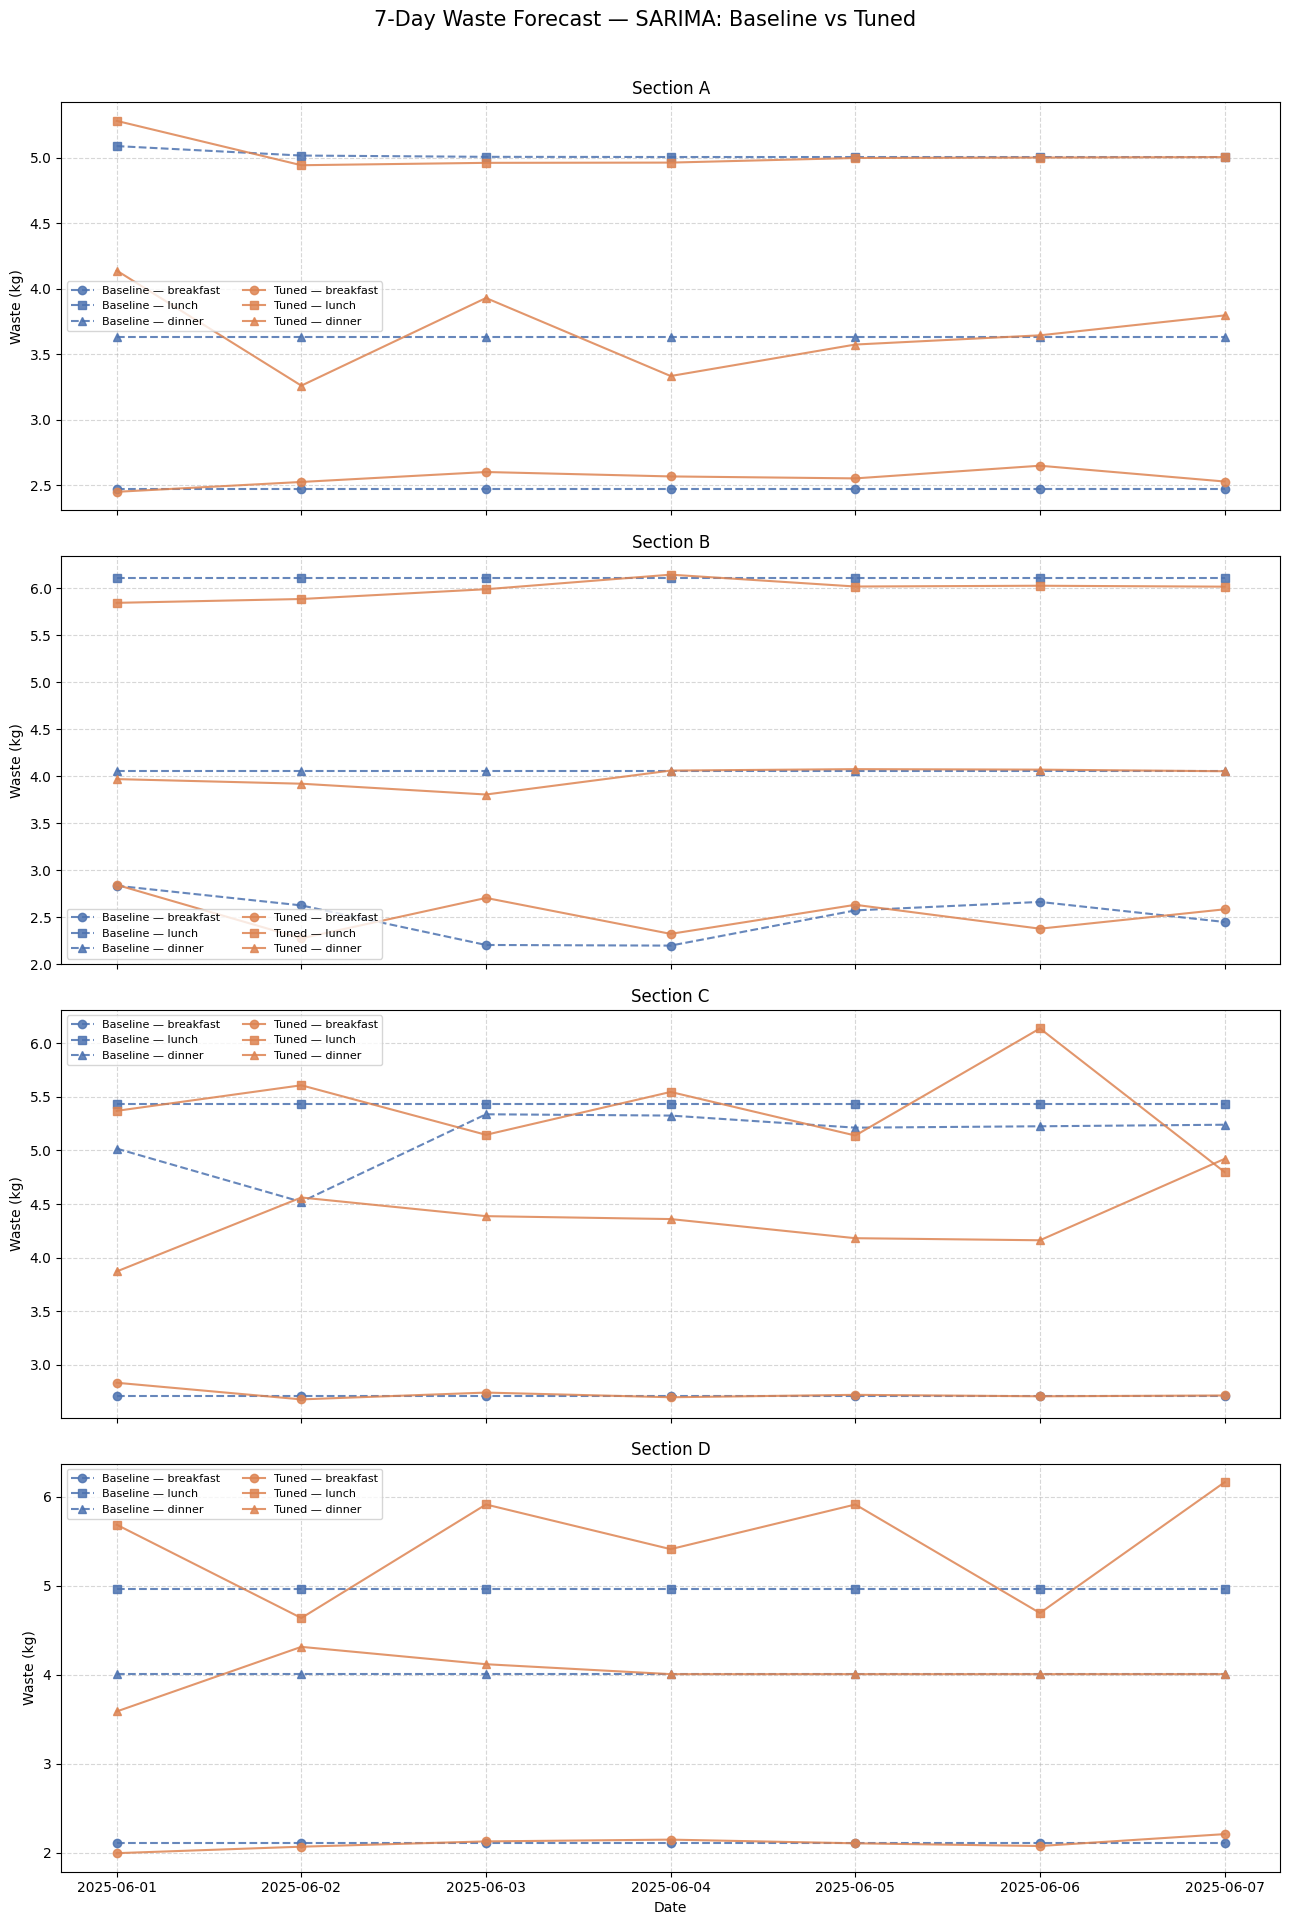

Figure saved to sarima_forecast_comparison.png


In [ ]:
# Compute forecast dates relative to last training date
last_train_date = splits['a']['breakfast']['train'].index.max()
forecast_dates  = pd.date_range(
    start=last_train_date + pd.Timedelta(days=1), periods=7)

all_comparison = {sec: {'Baseline': {}, 'Tuned': {}} for sec in SECTIONS}

for sec in SECTIONS:
    for meal in MEALS:
        for label in ['Baseline', 'Tuned']:
            prefix = 'baseline' if label == 'Baseline' else 'tuned'
            path = f'models/sarima_optimized/{prefix}_{sec}_{meal}.pkl'
            with open(path, 'rb') as f:
                m = pickle.load(f)
            preds = [max(0.0, p) for p in m.predict(n_periods=7).tolist()]
            all_comparison[sec][label][meal] = preds

plot_rows = [
    {'Date': date, 'Section': sec, 'Model': mname, 'Meal': meal, 'Forecast': val}
    for sec, model_dict in all_comparison.items()
    for mname, meal_dict in model_dict.items()
    for meal, preds in meal_dict.items()
    for date, val in zip(forecast_dates, preds)
]
plot_df = pd.DataFrame(plot_rows)

meal_styles   = {'breakfast': 'o', 'lunch': 's', 'dinner': '^'}
model_palette = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

fig, axes = plt.subplots(len(SECTIONS), 1, figsize=(13, 5 * len(SECTIONS)), sharex=True)
fig.suptitle('7-Day Waste Forecast — SARIMA: Baseline vs Tuned', fontsize=15)

for i, sec_key in enumerate(SECTIONS):
    ax  = axes[i]
    sub = plot_df[plot_df['Section'] == sec_key]
    for mname in ['Baseline', 'Tuned']:
        for meal in MEALS:
            s = sub[(sub['Model'] == mname) & (sub['Meal'] == meal)]
            ax.plot(s['Date'], s['Forecast'],
                    marker=meal_styles[meal],
                    color=model_palette[mname],
                    linestyle='-' if mname == 'Tuned' else '--',
                    alpha=0.85,
                    label=f'{mname} — {meal}')
    ax.set_title(f'Section {sec_key.upper()}')
    ax.set_ylabel('Waste (kg)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('metrics/sarima_forecast_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to sarima_forecast_comparison.png')
